# EDA

Fuente: bank marketing campaign

**Fuente: Bank Marketing Dataset**

| **Variable**           | **Definition**                                                                 |
|------------------------|--------------------------------------------------------------------------------|
| age                    | Edad del cliente (numérico)                                                   |
| job                    | Tipo de trabajo (categórico)                                                  |
| marital                | Estado civil (categórico)                                                     |
| education              | Nivel de educación (categórico)                                               |
| default                | ¿Tiene crédito actualmente? (categórico)                                      |
| housing                | ¿Tiene un préstamo de vivienda? (categórico)                                  |
| loan                   | ¿Tiene un préstamo personal? (categórico)                                     |
| contact                | Tipo de comunicación de contacto (categórico)                                 |
| month                  | Último mes en el que se le ha contactado (categórico)                         |
| day_of_week            | Último día en el que se le ha contactado (categórico)                         |
| duration               | Duración del contacto previo en segundos (numérico)                           |
| campaign               | Número de contactos durante esta campaña al cliente (numérico)                |
| pdays                  | Días desde el último contacto en una campaña anterior (numérico)              |
| previous               | Número de contactos realizados durante la campaña anterior (numérico)         |
| poutcome               | Resultado de la campaña de marketing anterior (categórico)                    |
| emp.var.rate           | Tasa de variación del empleo (trimestral, numérico)                           |
| cons.price.idx         | Índice de precios al consumidor (mensual, numérico)                           |
| cons.conf.idx          | Índice de confianza del consumidor (mensual, numérico)                        |
| euribor3m              | Tasa EURIBOR a 3 meses (diaria, numérico)                                     |
| nr.employed            | Número de empleados (trimestral, numérico)                                    |
| y                      | **TARGET**: ¿Contrata un depósito a largo plazo? (categórico)                 |

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix



In [3]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=';')


Informacion general del dataset 

In [4]:
df.shape


(41188, 21)

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Liempieza de datos

In [8]:
df.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

No existen valores nulos en ninguna columna de este dataset 

In [9]:
df.duplicated().sum()

np.int64(12)

Se eliminado 12 filas duplicadas que existian, igualmente coservando la primera copia.

In [10]:
df = df.drop_duplicates(keep='first')

Análisis univariado

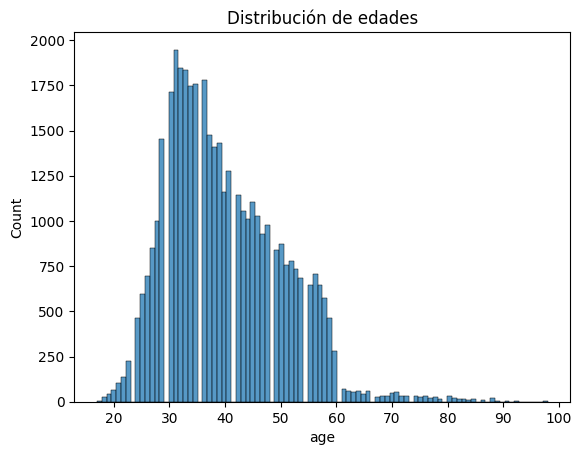

In [11]:
# Para columnas numéricas:

sns.histplot(df['age'])
plt.title("Distribución de edades")
plt.show()

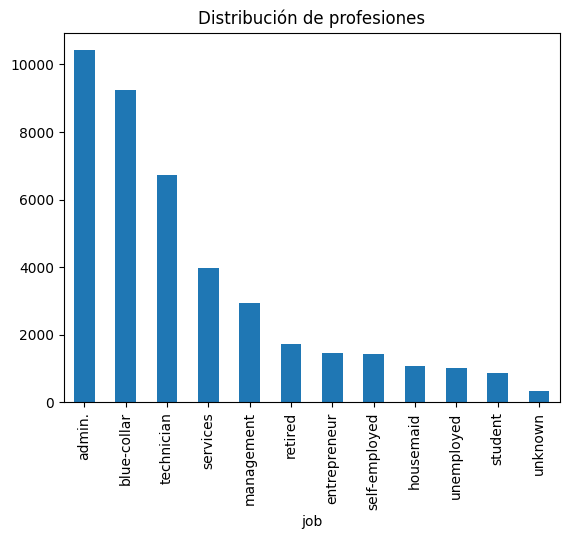

In [12]:
# Para columnas categóricas:

df['job'].value_counts().plot(kind='bar')
plt.title("Distribución de profesiones")
plt.show()

 Análisis bivariado

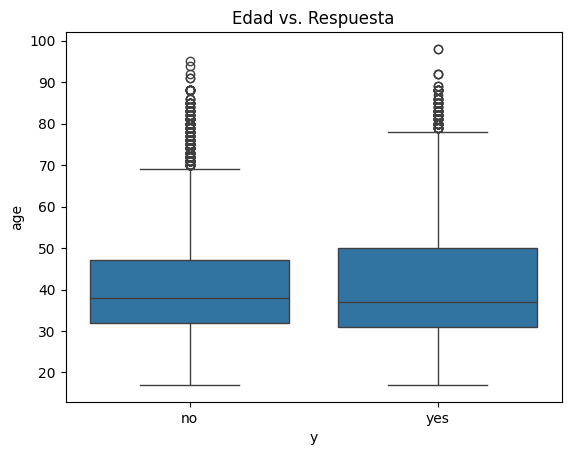

In [13]:
# Relación entre edad y respuesta al marketing:

sns.boxplot(data=df, x='y', y='age')
plt.title("Edad vs. Respuesta")
plt.show()

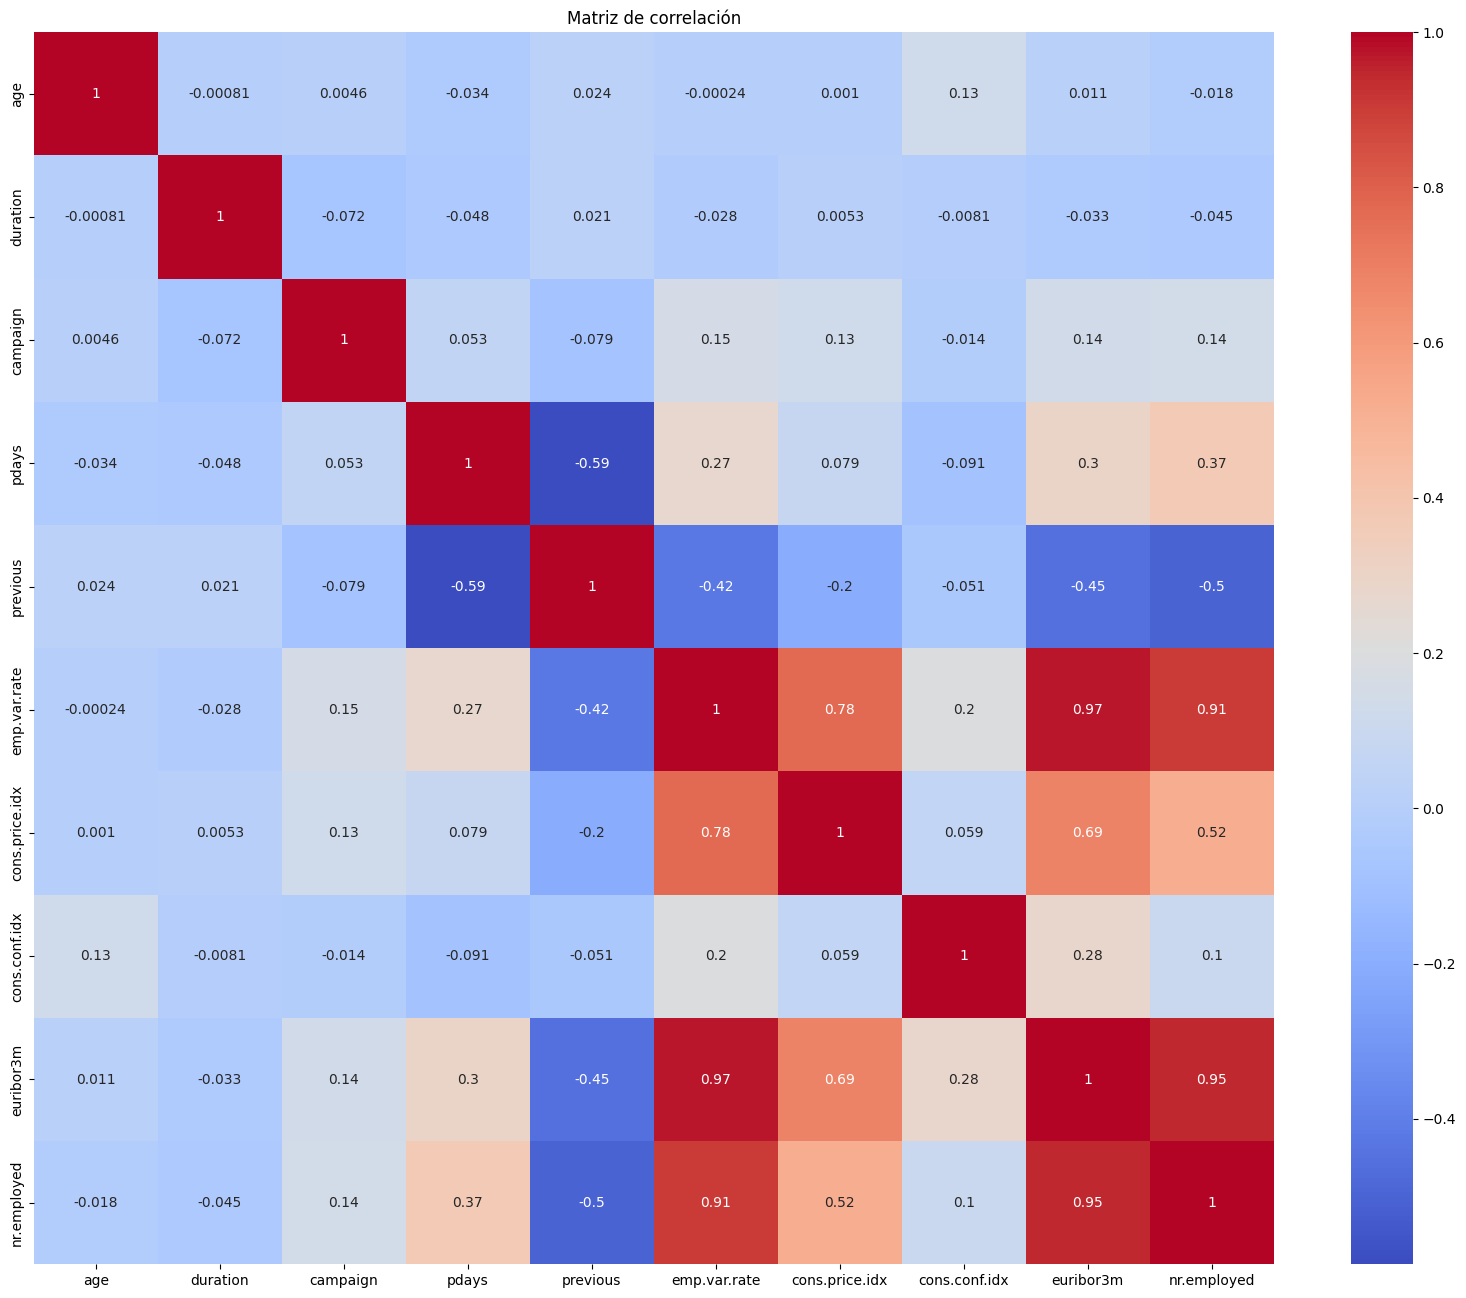

In [14]:
# Correlación entre variables numéricas:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16)) # Tamaño más grande para dar espacio
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Matriz de correlación")
plt.show()

Conclusion del eda 

El dataset de la campaña de marketing bancario no contiene valores nulos, lo que facilita el análisis.

Se identificaron y eliminaron 12 filas duplicadas, mejorando la calidad de los datos.

La variable age muestra una distribución sesgada hacia adultos de mediana edad, con pocos clientes jóvenes o muy mayores, esto puede influir en la respuesta a la campaña.

La variable categórica job tiene una distribución desigual, con algunas profesiones mucho más representadas que otras, lo que puede indicar segmentos de clientes más frecuentes o más propensos a ser contactados.

El análisis bivariado muestra que la edad puede influir en la respuesta a la campaña, ya que hay diferencias en la mediana de edad entre quienes aceptan y quienes no.

La matriz de correlación indica que no hay correlaciones fuertes entre las variables numéricas

Modelo de regresión logística

In [15]:
# Codificar la variable objetivo
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Codificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Separar variables predictoras y objetivo
X = df.drop('y', axis=1)
y = df['y']

# Escalar variables numéricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_test)

# Evaluar
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Matriz de confusión:
[[7066  199]
 [ 587  384]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7265
           1       0.66      0.40      0.49       971

    accuracy                           0.90      8236
   macro avg       0.79      0.68      0.72      8236
weighted avg       0.89      0.90      0.89      8236



Matriz de confusión

- 7066 clientes fueron correctamente clasificados como NO contrataron (verdaderos negativos).

- 384 clientes fueron correctamente clasificados como SÍ contrataron (verdaderos positivos).

- 199 clientes fueron clasificados incorrectamente como sí, pero en realidad no contrataron (falsos positivos).

- 587 clientes fueron clasificados como no, pero en realidad sí contrataron (falsos negativos).

Interpretación por clase:

 - Clase 0 (no contrató): 

Precisión: 92% → cuando el modelo predice "no", acierta el 92% de las veces.

Recall: 97% → detecta correctamente el 97% de los clientes que realmente no contrataron.

F1-score: 0.95 → excelente balance entre precisión y recall.

- Clase 1 (sí contrató):

Precisión: 66% → de los que el modelo predice que contratarán, el 66% lo hacen realmente.

Recall: 40% → detecta solo el 40% de los clientes que realmente contrataron.

F1-score: 0.49 → rendimiento bajo, indica que el modelo no es bueno detectando a los clientes interesados.



Conclusión General:


El modelo tiene un buen desempeño general (accuracy del 90%), pero eso se debe a que la mayoría de los clientes no contratan, y el modelo predice muy bien esa clase.

Sin embargo, tiene dificultades para identificar correctamente a los clientes que sí contratan (recall bajo en clase 1).

Esto puede ser un problema en campañas de marketing, ya que el modelo podría perder muchas oportunidades al no detectar clientes interesados.




